# Climate Forecasting with Spatiotemporal Deep Learning

This notebook demonstrates a workflow for climate forecasting using ERA5 atmospheric pressure-level data and deep learning models. 

The objective is to explore how spatiotemporal neural networks can learn patterns from atmospheric data and generate short-term climate predictions.

## Import Required Libraries

Load Python libraries used for numerical computation, deep learning, and visualization.

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [8]:
import sys
import os

sys.path.append(os.path.abspath(".."))

## Load Processed ERA5 Atmospheric Dataset

The dataset contains spatiotemporal atmospheric variables extracted from ERA5 reanalysis data.

Input tensors contain multiple time steps and atmospheric variables used to train the forecasting model.

In [23]:
data = np.load("../data_processed/era5_pl_seus_2024_01_Tin6_Tout12.npz")

print("Available arrays:", data.files)
print("X_train shape:", data["X_train"].shape)
print("Y_train shape:", data["Y_train"].shape)

Available arrays: ['X_train', 'Y_train', 'X_val', 'Y_val', 'mean', 'std', 'levels', 't_in', 't_out', 'H', 'W', 'in_channels', 'out_channels']
X_train shape: (120, 6, 37, 61, 25)
Y_train shape: (120, 37, 61, 5)


## Visualizing an Example Atmospheric Input Field

This visualization shows one atmospheric variable from the dataset at a single time step.  
Each pixel represents a spatial grid location in the atmospheric pressure field.

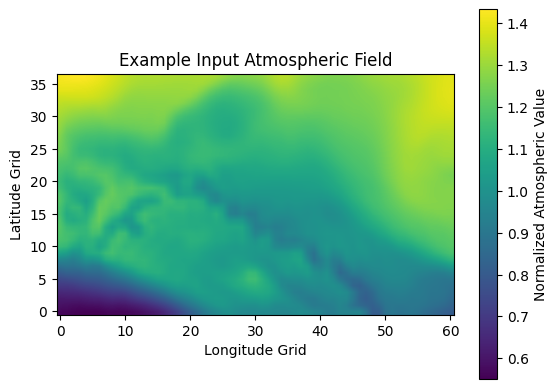

In [25]:
plt.imshow(sample[0, :, :, 0], origin="lower", interpolation="bilinear")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.title("Example Input Atmospheric Field")
plt.colorbar(label="Normalized Atmospheric Value")
plt.show()

## Load Trained ConvLSTM Forecasting Model

A trained ConvLSTM neural network is loaded from a checkpoint.  
This model learns spatial and temporal relationships in atmospheric fields to generate future climate predictions.

In [13]:
from src.training.spatiotemporal_module import LitForecaster

ckpt = "../checkpoints/convlstm-era5_pl_seus_2024_01_Tin6_Tout12-epoch=12-val_mse=0.027535.ckpt"

model = LitForecaster.load_from_checkpoint(ckpt)
model.eval()

LitForecaster(
  (model): ConvLSTMForecaster(
    (cell): ConvLSTMCell(
      (conv): Conv2d(57, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (head): Conv2d(32, 5, kernel_size=(1, 1), stride=(1, 1))
  )
)

### Model Prediction

Using a trained ConvLSTM model to generate atmospheric forecasts.

In [16]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = model.to(device)

In [17]:
import numpy as np
import torch

data = np.load("../data_processed/era5_pl_seus_2024_01_Tin6_Tout12.npz")

X = torch.tensor(data["X_train"][:1]).float().to(device)

with torch.no_grad():
    pred = model(X)

pred = pred.cpu().numpy()

print(pred.shape)

(1, 37, 61, 5)


## Predicted Atmospheric Field

The model output represents the predicted atmospheric variable across the spatial grid.

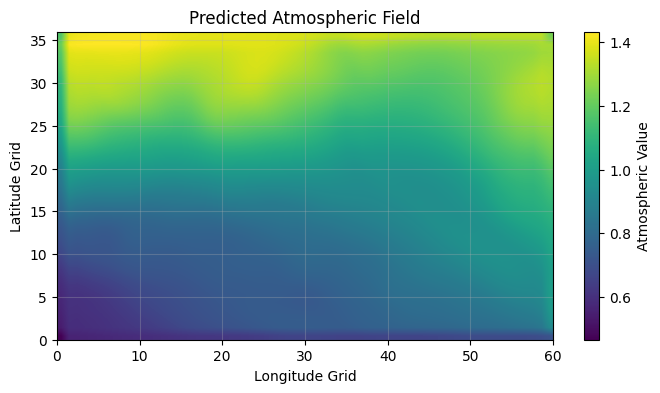

In [19]:
import numpy as np
import matplotlib.pyplot as plt


H, W = pred.shape[1], pred.shape[2]

# create coordinate scale
x = np.linspace(0, W-1, W)
y = np.linspace(0, H-1, H)

plt.figure(figsize=(8,4))

plt.imshow(
    pred[0, :, :, 0],
    origin="lower",
    extent=[x.min(), x.max(), y.min(), y.max()],
    interpolation="bilinear",
    aspect="auto"
)

plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.title("Predicted Atmospheric Field")

plt.colorbar(label="Atmospheric Value")

plt.grid(alpha=0.3)

plt.show()

# Input vs Forecast Comparison
This visualization compares the original atmospheric field with the ConvLSTM model forecast. 
It illustrates how the model captures large-scale spatial patterns in atmospheric data.

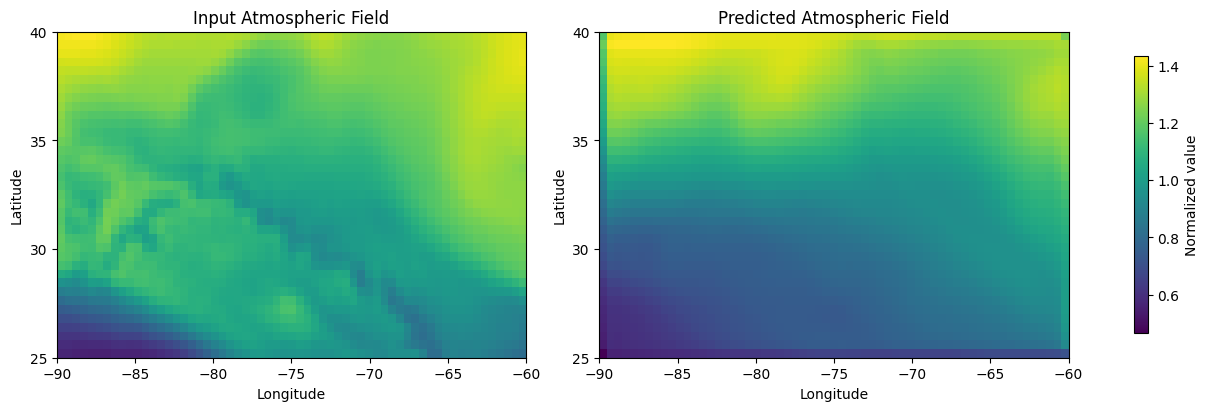

In [32]:
import matplotlib.pyplot as plt
import numpy as np

k = 0

inp = sample[0, :, :, 0]     # example input field
out = pred[0, :, :, k]       # predicted field

vmin = min(inp.min(), out.min())
vmax = max(inp.max(), out.max())

lon_min, lon_max = -90, -60
lat_min, lat_max = 25, 40
extent = [lon_min, lon_max, lat_min, lat_max]

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

im1 = ax[0].imshow(inp, origin="lower", extent=extent, vmin=vmin, vmax=vmax, aspect="auto")
ax[0].set_title("Input Atmospheric Field")
ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")

im2 = ax[1].imshow(out, origin="lower", extent=extent, vmin=vmin, vmax=vmax, aspect="auto")
ax[1].set_title("Predicted Atmospheric Field")
ax[1].set_xlabel("Longitude")
ax[1].set_ylabel("Latitude")

# nice ticks
ax[0].set_xticks(np.linspace(lon_min, lon_max, 7))
ax[0].set_yticks(np.linspace(lat_min, lat_max, 4))
ax[1].set_xticks(np.linspace(lon_min, lon_max, 7))
ax[1].set_yticks(np.linspace(lat_min, lat_max, 4))

fig.colorbar(im2, ax=ax.ravel().tolist(), shrink=0.85, label="Normalized value")
plt.show()